# JUMP → AnnData (single cell)

The [well-level notebook](jump_to_anndata.ipynb) builds one observation per well from the
assembled profiles. This one builds **one observation per segmented cell** from the raw
CellProfiler output those profiles were aggregated from.

That output lives in the [Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/)
under `cpg0016-jump/<source>/workspace/backend/<batch>/<plate>/<plate>.sqlite` — one SQLite
database per plate with `Image`, `Cells`, `Cytoplasm`, and `Nuclei` tables, no feature
selection and no normalization applied. A plate is **~37 GB**.

`USE_SUBSET` (on by default) sidesteps that: it pulls only the first ~1 GB of the
per-plate CellProfiler CSVs and rebuilds a small SQLite with the same schema, so the rest
of the notebook is unchanged. The [appendix](#Appendix--the-1-GB-subset) explains the
trade-off; set `USE_SUBSET = False` and point `CELL_DB` at a full `.sqlite` for the
real thing. The closing table lists every way this notebook differs from the well-level one.

> **Outputs not committed.** The download was too slow to finish where this was written;
> `build_subset_db` and the compartment join were checked against a partial pull. Run it
> yourself — every cell is sized for the ~1 GB subset.

In [ ]:
from __future__ import annotations

import subprocess
import time
from collections.abc import Iterable, Sequence
from pathlib import Path

import anndata as ad
import duckdb
import numpy as np
import pandas as pd
import scanpy as sc

DATA_ROOT = Path("~/data/jump-cellpainting-datasets").expanduser()  # the well-level metadata checkout
CELL_ROOT = Path("~/data/jump-single-cell").expanduser()

SOURCE = "source_13"
BATCH = "20220914_Run1"
PLATE = "CP-CC9-R1-01"  # a CRISPR plate, so SUBSET below matches the well-level notebook
SUBSET = "crispr"

USE_SUBSET = True
SUBSET_BYTES = 330_000_000  # head of each compartment CSV; x3 + a full Image.csv ≈ 1 GB
MAX_IMAGES = None  # with USE_SUBSET the pull is already small; set an int to cap a full plate
SAMPLE_CELLS = 40_000  # random cells kept for PCA/UMAP; None keeps all

CPG_S3 = "s3://cellpainting-gallery/cpg0016-jump"

## Fetching the cells

`fetch_single_cell_db` pulls the whole ~37 GB plate database with the AWS CLI (no
credentials needed for this bucket). `build_subset_db` is the cheap alternative: the
per-plate CellProfiler run is also published as four flat CSVs under
`workspace/analysis/…`, and an HTTP range request takes just the head of each object
table. Those prefixes are loaded into a local SQLite whose `Image` / `Cells` /
`Cytoplasm` / `Nuclei` tables match the real backend, so `load_cells` below does not care
which path produced `CELL_DB`.

In [4]:
def fetch_single_cell_db(root: Path, source: str, batch: str, plate: str) -> Path:
    dest = root / source / batch / plate / f"{plate}.sqlite"
    if not dest.exists():
        dest.parent.mkdir(parents=True, exist_ok=True)
        uri = f"{CPG_S3}/{source}/workspace/backend/{batch}/{plate}/{plate}.sqlite"
        print(f"downloading {uri}  (~37 GB)")
        subprocess.run(["aws", "s3", "cp", uri, str(dest), "--no-sign-request"], check=True)
    return dest


def _range_get(key: str, n_bytes: int | None, dest: Path) -> None:
    if dest.exists() and (n_bytes is None or dest.stat().st_size >= n_bytes):
        return  # resume: already have (enough of) this file
    cmd = ["aws", "s3api", "get-object", "--bucket", "cellpainting-gallery", "--key", key, "--no-sign-request"]
    if n_bytes is not None:
        cmd += ["--range", f"bytes=0-{n_bytes - 1}"]
    for attempt in range(4):  # S3 endpoint errors are transient
        if subprocess.run([*cmd, str(dest)], stdout=subprocess.DEVNULL, check=False).returncode == 0:
            return
        time.sleep(5 * (attempt + 1))
    raise RuntimeError(f"could not fetch {key}")


def build_subset_db(root: Path, source: str, batch: str, plate: str, n_bytes: int) -> Path:
    dest = root / source / batch / plate / f"{plate}_subset.sqlite"
    if dest.exists():
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    prefix = f"cpg0016-jump/{source}/workspace/analysis/{batch}/{plate}/analysis/{plate}"
    raw = {name: dest.parent / f"{name}.csv" for name in ("Image", "Cells", "Cytoplasm", "Nuclei")}
    for name, budget in (("Image", None), ("Cells", n_bytes), ("Cytoplasm", n_bytes), ("Nuclei", n_bytes)):
        print(f"fetching {name}.csv" + ("" if budget is None else f" (first {budget // 10**6} MB)"))
        _range_get(f"{prefix}/{name}.csv", budget, raw[name])

    con = duckdb.connect()
    con.execute("INSTALL sqlite; LOAD sqlite")
    con.execute(f"ATTACH '{dest}' AS out (TYPE sqlite)")
    con.execute(
        f"CREATE TABLE out.Image AS SELECT Image_ImageNumber AS ImageNumber, "
        f"Metadata_Plate, Metadata_Well, Metadata_Site FROM read_csv('{raw['Image']}', sample_size=-1)"
    )
    ceilings = []
    for name in ("Cells", "Cytoplasm", "Nuclei"):
        con.execute(
            f"CREATE TABLE out.{name} AS SELECT * FROM read_csv('{raw[name]}', sample_size=-1, ignore_errors=true)"
        )
        top = con.sql(f"SELECT max(ImageNumber) FROM out.{name}").fetchone()[0]
        con.execute(f"DELETE FROM out.{name} WHERE ImageNumber = {top}")  # last image is only partly downloaded
        ceilings.append(con.sql(f"SELECT max(ImageNumber) FROM out.{name}").fetchone()[0])
    for name in ("Image", "Cells", "Cytoplasm", "Nuclei"):
        con.execute(f"DELETE FROM out.{name} WHERE ImageNumber > {min(ceilings)}")
    con.close()
    for path in raw.values():
        path.unlink()
    return dest


if USE_SUBSET:
    CELL_DB = build_subset_db(CELL_ROOT, SOURCE, BATCH, PLATE, SUBSET_BYTES)
else:
    CELL_DB = fetch_single_cell_db(CELL_ROOT, SOURCE, BATCH, PLATE)
CELL_DB

PosixPath('/Users/luisheinzlmeier/data/jump-single-cell/source_13/20220914_Run1/CP-CC9-R1-01/CP-CC9-R1-01_subset.sqlite')

## Joining the three compartments

CellProfiler writes one table per segmented object class. A *cell* is the join of a
`Cells` row with the `Cytoplasm` and `Nuclei` rows that belong to it — `Cytoplasm` carries
the parent links (`Cytoplasm_Parent_Cells`, `Cytoplasm_Parent_Nuclei`), matched to each
compartment's `ObjectNumber` within the same `ImageNumber`. `Image` adds well and site.
The well-level parquet is already past this join; here it is explicit.

In [5]:
_FEATURE_PREFIXES = ("Cells_", "Cytoplasm_", "Nuclei_")


def _read_table(con: duckdb.DuckDBPyConnection, table: str, where: str) -> pd.DataFrame:
    return con.sql(f"SELECT * FROM db.{table} {where}").df()


def load_cells(db_path: Path, max_images: int | None) -> ad.AnnData:
    con = duckdb.connect()
    con.execute("INSTALL sqlite; LOAD sqlite; SET sqlite_all_varchar = false")
    con.execute(f"ATTACH '{db_path}' AS db (TYPE sqlite, READ_ONLY)")
    where = "" if max_images is None else f"WHERE ImageNumber <= {int(max_images)}"

    image = con.sql(f"SELECT ImageNumber, Metadata_Plate, Metadata_Well, Metadata_Site FROM db.Image {where}").df()
    cells = _read_table(con, "Cells", where)
    cyto = _read_table(con, "Cytoplasm", where)
    nuclei = _read_table(con, "Nuclei", where)
    con.close()

    merged = (
        cyto.merge(
            cells,
            left_on=["ImageNumber", "Cytoplasm_Parent_Cells"],
            right_on=["ImageNumber", "ObjectNumber"],
            suffixes=("", "_cells"),
        )
        .merge(
            nuclei,
            left_on=["ImageNumber", "Cytoplasm_Parent_Nuclei"],
            right_on=["ImageNumber", "ObjectNumber"],
            suffixes=("", "_nuclei"),
        )
        .merge(image, on="ImageNumber")
    )

    feature_cols = [c for c in merged.columns if c.startswith(_FEATURE_PREFIXES)]
    obs = pd.DataFrame(
        {
            "Source": SOURCE,
            "Plate": merged["Metadata_Plate"].to_numpy(),
            "Well": merged["Metadata_Well"].to_numpy(),
            "Site": merged["Metadata_Site"].astype(str).to_numpy(),
            "ImageNumber": merged["ImageNumber"].to_numpy(),
            "cell_id": merged["Cytoplasm_Parent_Cells"].to_numpy(),
        }
    )
    obs.index = pd.Index(
        obs["Source"] + ":" + obs["Plate"] + ":" + obs["Well"] + ":" + obs["Site"] + ":" + obs["cell_id"].astype(str),
        name="cell",
    )
    var = pd.DataFrame(index=pd.Index(feature_cols, name="feature"))

    adata = ad.AnnData(X=merged[feature_cols].to_numpy(np.float32), obs=obs, var=var)
    adata.uns["subset"] = SUBSET
    adata.uns["source_db"] = db_path.name
    return adata


adata = load_cells(CELL_DB, MAX_IMAGES)
adata

AnnData object with n_obs × n_vars = 14973 × 3673
    obs: 'Source', 'Plate', 'Well', 'Site', 'ImageNumber', 'cell_id'
    uns: 'subset', 'source_db'
    layers: None (.X)

## Well and perturbation annotation

Every cell in a well shares that well's perturbation, so the well-level joins are the same
— `well` for the `JCP2022` id, `plate` for batch and plate type, `perturbation_control`
for the control flag, the per-modality table (`crispr` here) for the gene — just broadcast
down to cell resolution.

In [6]:
def read_meta(root: Path, name: str) -> pd.DataFrame:
    for suffix in (".csv", ".csv.gz"):
        path = root / "metadata" / f"{name}{suffix}"
        if path.exists():
            return pd.read_csv(path).rename(columns=lambda c: c.removeprefix("Metadata_"))
    raise FileNotFoundError(root / "metadata" / f"{name}.csv[.gz]")


def add_well_metadata(adata: ad.AnnData, root: Path, subset: str) -> None:
    well = read_meta(root, "well").set_index(["Source", "Plate", "Well"])["JCP2022"]
    adata.obs = adata.obs.join(well, on=["Source", "Plate", "Well"])

    plate = read_meta(root, "plate").set_index(["Source", "Plate"])[["Batch", "PlateType"]]
    adata.obs = adata.obs.join(plate, on=["Source", "Plate"])

    control = read_meta(root, "perturbation_control")
    control = control[control["modality"].isin([subset, "any"])].set_index("JCP2022")
    adata.obs = adata.obs.join(control[["pert_type", "Name"]].rename(columns={"Name": "control_name"}), on="JCP2022")
    adata.obs["pert_type"] = adata.obs["pert_type"].fillna("trt")

    pert = read_meta(root, subset).drop_duplicates("JCP2022").set_index("JCP2022")
    adata.obs = adata.obs.join(pert[["Symbol", "NCBI_Gene_ID"]].rename(columns=str.lower), on="JCP2022")


def categorize(adata: ad.AnnData, columns: Iterable[str]) -> None:
    for column in columns:
        adata.obs[column] = adata.obs[column].astype("category")


add_well_metadata(adata, DATA_ROOT, SUBSET)
categorize(
    adata, ["Source", "Plate", "Well", "Site", "JCP2022", "Batch", "PlateType", "pert_type", "control_name", "symbol"]
)
adata.obs.head()

,Source,Plate,Well,Site,ImageNumber,cell_id,JCP2022,Batch,PlateType,pert_type,control_name,symbol,ncbi_gene_id
cell,,,,,,,,,,,,,
source_13:CP-CC9-R1-01:A02:0:1,source_13,CP-CC9-R1-01,A02,0,10101,1,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN
source_13:CP-CC9-R1-01:A02:0:2,source_13,CP-CC9-R1-01,A02,0,10101,2,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN
source_13:CP-CC9-R1-01:A02:0:3,source_13,CP-CC9-R1-01,A02,0,10101,3,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN
source_13:CP-CC9-R1-01:A02:0:4,source_13,CP-CC9-R1-01,A02,0,10101,4,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN
source_13:CP-CC9-R1-01:A02:0:5,source_13,CP-CC9-R1-01,A02,0,10101,5,JCP2022_800002,20220914_Run1,CRISPR,negcon,non-targeting,non-targeting,NaN


## Feature annotation

Same derivation as the well-level notebook, but the compartment token is now the full
CellProfiler name (`Cells` / `Cytoplasm` / `Nuclei`) rather than the abbreviation the
assembled profiles use.

In [7]:
CHANNELS: Sequence[str] = ("DNA", "RNA", "AGP", "ER", "Mito")


def annotate_features(var: pd.DataFrame, channels: Sequence[str] = CHANNELS) -> None:
    tokens = [name.split("_") for name in var.index]
    matched = [[t for t in token if t in channels] for token in tokens]
    var["compartment"] = pd.Categorical([t[0] for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([c[0] if c else None for c in matched])
    var["channel_2"] = pd.Categorical([c[1] if len(c) > 1 else None for c in matched])
    var["n_channels"] = np.array([len(c) for c in matched], dtype=np.int8)


annotate_features(adata.var)
adata.var["family"].value_counts()

family
Texture               2340
RadialDistribution     402
Correlation            240
Granularity            240
Intensity              225
AreaShape              161
Location                33
Neighbors               21
ObjectSkeleton           4
Parent                   3
Children                 2
Number                   2
Name: count, dtype: int64

Feature selection has *not* run on this matrix, so the object-tracking bookkeeping is all
still here: `Number`, `Parent` (including the `Cytoplasm_Parent_*` links used for the join),
`Children`, `Location`, the neighbour object-id columns, and the `AreaShape` bounding-box /
centre coordinates. None of it is phenotype — drop it.

In [8]:
_DROP_FAMILIES = ("Number", "Parent", "Children", "Location")
_DROP_TOKENS = ("BoundingBox", "Center", "ObjectNumber")

by_family = adata.var["family"].isin(_DROP_FAMILIES).to_numpy()
by_token = np.array([any(tok in name for tok in _DROP_TOKENS) for name in adata.var_names])
adata = adata[:, ~(by_family | by_token)].copy()

## Per-cell QC

Drop any cell with a non-finite feature (edge cells, failed measurements) and put a hard
floor on nucleus area to clear segmentation debris.

In [9]:
finite = np.isfinite(adata.X).all(axis=1)
area = adata[:, "Nuclei_AreaShape_Area"].X.ravel()
keep = finite & (area > np.nanquantile(area, 0.01))
print(f"dropping {int((~keep).sum())} / {adata.n_obs} cells (edge / debris / non-finite)")
adata = adata[keep].copy()

dropping 184 / 14973 cells (edge / debris / non-finite)


## Normalization

The well-level profiles arrive MAD-robustized per plate against the negative controls;
here that runs in the notebook, on cells — subtract the median and divide by the scaled
MAD of this plate's `negcon` cells, feature by feature. Raw values stay in
`adata.layers["cellprofiler"]`.

In [10]:
def mad_robustize(adata: ad.AnnData, control_mask: np.ndarray) -> None:
    adata.layers["cellprofiler"] = adata.X.copy()
    X = adata.X.astype(np.float64)
    ref = X[control_mask]
    median = np.median(ref, axis=0)
    mad = np.median(np.abs(ref - median), axis=0) * 1.4826
    scale = np.where(mad == 0, np.nan, mad)
    adata.X = ((X - median) / scale).astype(np.float32)


mad_robustize(adata, adata.obs["pert_type"].eq("negcon").to_numpy())

finite_cols = np.isfinite(adata.X).all(axis=0)
print(f"dropping {int((~finite_cols).sum())} zero-MAD features")
adata = adata[:, finite_cols].copy()

dropping 375 zero-MAD features


## Sanity checks

In [11]:
counts = adata.obs["Well"].value_counts()
print(f"{adata.n_obs:,} cells x {adata.n_vars:,} features")
print(
    f"wells: {adata.obs['Well'].nunique()}   cells/well min/median/max: {counts.min()}/{int(counts.median())}/{counts.max()}"
)
print(f"genes: {adata.obs['symbol'].nunique()}")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs["pert_type"].value_counts())

14,789 cells x 3,231 features
wells: 6   cells/well min/median/max: 1329/2464/3590
genes: 6
non-finite values: 0
pert_type
trt       11384
negcon     3405
Name: count, dtype: int64


In [12]:
adata.write_h5ad(CELL_ROOT / f"jump_{SUBSET}_{PLATE}_cells.h5ad")

## UMAP

PCA and the neighbour graph run on a random subsample when the cell count is large.

In [13]:
view = adata
if SAMPLE_CELLS is not None and adata.n_obs > SAMPLE_CELLS:
    rng = np.random.default_rng(0)
    view = adata[rng.choice(adata.n_obs, SAMPLE_CELLS, replace=False)].copy()

sc.pp.pca(view, n_comps=50)
sc.pp.neighbors(view, n_neighbors=15)
sc.tl.umap(view)

/Users/luisheinzlmeier/miniforge3/envs/cellpainting/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Measure the structure before reading the picture: how often do neighbouring *cells* share
a label, against a shuffled baseline?

In [14]:
def neighbour_enrichment(adata: ad.AnnData, keys: Iterable[str]) -> pd.DataFrame:
    graph = adata.obsp["connectivities"].tocoo()
    rows = []
    for key in keys:
        labels = adata.obs[key].to_numpy()
        observed = float((labels[graph.row] == labels[graph.col]).mean())
        baseline = float((adata.obs[key].value_counts(normalize=True).to_numpy() ** 2).sum())
        rows.append({"covariate": key, "observed": observed, "baseline": baseline, "ratio": observed / baseline})
    return pd.DataFrame(rows).set_index("covariate").round(3)


area = view[:, "Nuclei_AreaShape_Area"].layers["cellprofiler"].ravel()
view.obs["area_bin"] = pd.qcut(area, 5, labels=[f"area Q{i}" for i in range(1, 6)])
neighbour_enrichment(view, ["Well", "Site", "pert_type", "symbol", "area_bin"])

,observed,baseline,ratio
covariate,,,
Well,0.328,0.188,1.744
Site,0.266,0.118,2.245
pert_type,0.700,0.646,1.084
symbol,0.328,0.188,1.744
area_bin,0.224,0.200,1.120


Even after per-plate normalization, *position* carries the neighbour graph: same-site
cells are the most enriched (shared field of view — illumination, local cell density),
then same-well cells, with cell-size and `pert_type` only just above chance. In this
six-well subset `Well` and `symbol` score identically because one well is one CRISPR
gene, so the perturbation cannot be told apart from the plate-position it sits at. This
is the whole reason the consortium aggregates cells to a well profile and scores it
against matched controls rather than clustering cells.

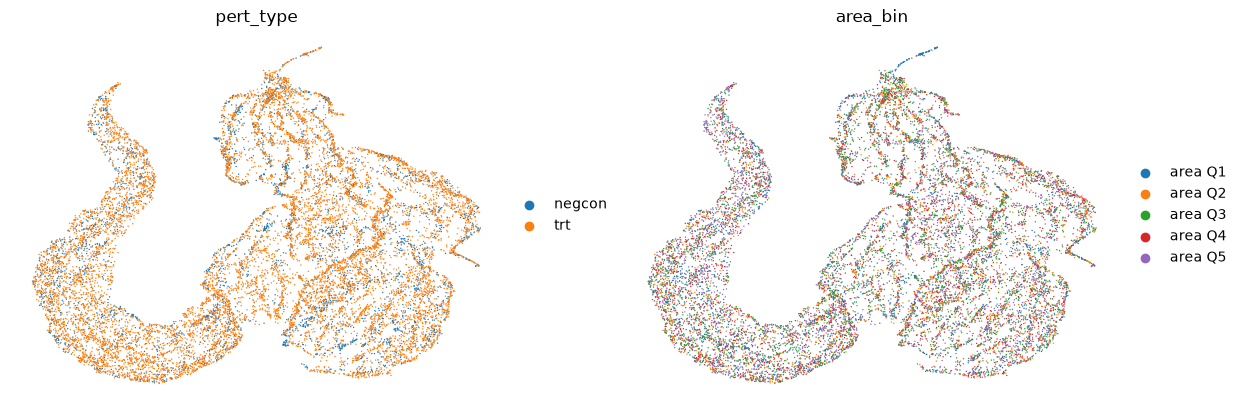

In [15]:
sc.pl.umap(view, color=["pert_type", "area_bin"], ncols=2, frameon=False, size=4)

## What changes from `jump_to_anndata.ipynb`

| Step | Well-level notebook | This notebook |
|---|---|---|
| **Source** | one assembled parquet per modality from `cpg0016-jump-assembled` (via `profile_index.json`), already feature-selected + MAD-robustized | one `*.sqlite` per **plate** from `cpg0016-jump/.../workspace/backend`, ~37 GB, raw CellProfiler output — or its first ~1 GB via the CSV mirror under `workspace/analysis` |
| **Fetch** | `fsspec.open` streams one file | `aws s3 cp` a whole plate, **or** `build_subset_db` HTTP-range-gets the head of each compartment CSV and rebuilds a matching SQLite |
| **Row / `obs` axis** | one well; index `source:plate:well` | one segmented cell; index `source:plate:well:site:cell` |
| **Assembling `X`** | read columns straight from the parquet | join `Cells` ⨝ `Cytoplasm` ⨝ `Nuclei` on the parent-object links within an image, then attach `Image` for well/site |
| **`obs` columns** | Source, Plate, Well, JCP2022 + joins | adds Site, ImageNumber, cell_id |
| **Metadata joins** | `well`/`plate`/`perturbation_control`/`crispr` keyed by well | the same tables, broadcast from wells down to their cells |
| **Feature set** | `Cells_` / `Cytoplasm_` / `Nuclei_`, feature-selected | same prefixes, **no** selection; the `Number` / `Parent` / `Children` / `Location` / neighbour-id / bounding-box columns are still present and dropped in-notebook |
| **QC** | wells already outlier-filtered upstream | per-cell filter here: non-finite features, tiny-nucleus debris |
| **Normalization** | done upstream; `X` enters PCA unscaled | `mad_robustize` runs **here**, against `negcon` **cells** on this plate; zero-MAD features dropped after |
| **Scale** | ~50k wells for a whole modality | 10⁴–10⁶ cells for **one plate** (or a few wells with the subset); PCA/neighbours/UMAP on a random `SAMPLE_CELLS` draw |
| **`neighbour_enrichment`** | Plate, Batch, pert_type, gene | Well, Site, pert_type, gene, **cell-size bin** — cell state, not perturbation, dominates |
| **Output** | `jump_<subset>.h5ad` | `jump_<subset>_<plate>_cells.h5ad`, plus a `cellprofiler` raw layer |

Unchanged: `read_meta`, `add_well_metadata`, `annotate_features`, the `CHANNELS` list, the
bookkeeping drop, and `neighbour_enrichment` itself.

## Appendix — the ~1 GB subset

The full backend SQLite is ~37 GB and SQLite has no useful partial-read: its b-trees are
interleaved, so a truncated copy is unusable, and a remote `ATTACH` over HTTP is far too
slow for a full scan. What *does* work is the parallel CSV export of the same
CellProfiler run, under `cpg0016-jump/<source>/workspace/analysis/<batch>/<plate>/analysis/<plate>/`:

* `Image.csv` (~80 MB) — pulled whole; gives `ImageNumber → well, site`.
* `Cells.csv`, `Cytoplasm.csv`, `Nuclei.csv` (~20–25 GB each) — only the first
  `SUBSET_BYTES` of each is fetched with an HTTP `Range` header. A CSV prefix is still
  valid CSV; the final truncated row and its (partial) image are dropped, and the three
  tables are clipped to their common last `ImageNumber`.

`build_subset_db` loads those into a local SQLite with the same four tables the backend
has, so nothing downstream changes. At ~1 GB the prefix reaches only the **first handful
of wells** the plate was processed in — enough for the join, the metadata, the
normalization (the first well, `A02`, is the non-targeting control), and a UMAP, but not a
plate-wide analysis. Raise `SUBSET_BYTES`, or set `USE_SUBSET = False` and give `CELL_DB`
a full `.sqlite`, for that.